In [1]:
import torch
from diffusers import DDPMPipeline

from genaibook.core import get_device

In [3]:
device = get_device()

pipe = DDPMPipeline.from_pretrained(
    "google/ddpm-celebahq-256"
)
pipe.to(device)

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

c:\Conda\envs\Handsongenai\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Deep work\.cache\huggingface\hub\models--google--ddpm-celebahq-256. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Deep work\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Deep work\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

  0%|          | 0/1000 [00:00<?, ?it/s]

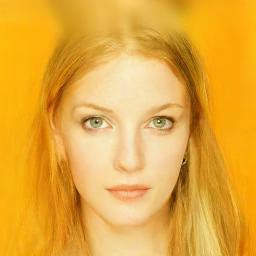

In [4]:
pipe().images[0]

In [5]:
from genaibook.core import plot_noise_and_denoise

image = torch.randn(4,3,256,256).to(device) #x_T sampled for diffusion model
pipe.scheduler.set_timesteps(num_inference_steps=30)

In [6]:
pipe.scheduler.timesteps

tensor([957, 924, 891, 858, 825, 792, 759, 726, 693, 660, 627, 594, 561, 528,
        495, 462, 429, 396, 363, 330, 297, 264, 231, 198, 165, 132,  99,  66,
         33,   0])

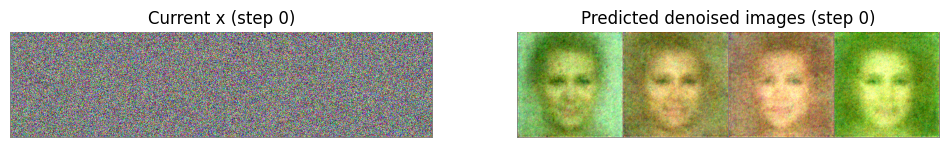

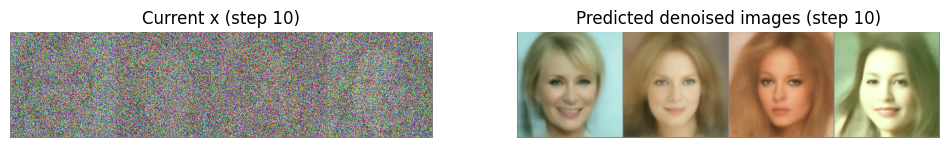

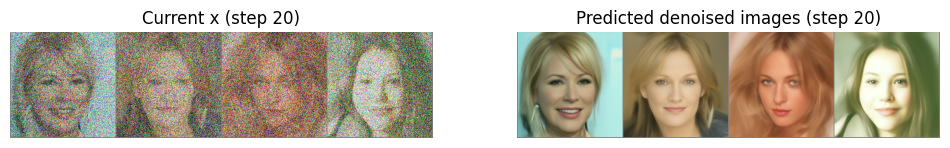

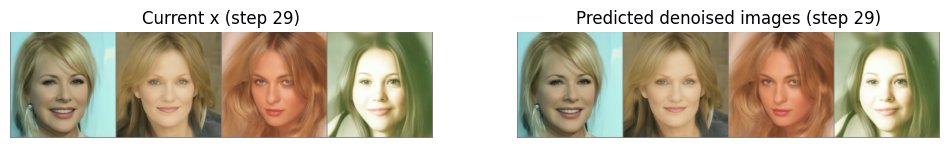

In [7]:
for i, t in enumerate(pipe.scheduler.timesteps):
    with torch.inference_mode():
        noise_pred = pipe.unet(image,t)["sample"]
    
    scheduler_output = pipe.scheduler.step(noise_pred,t,image)

    image = scheduler_output.prev_sample

    if (i % 10 == 0) or (i == len(pipe.scheduler.timesteps) - 1):
        plot_noise_and_denoise(scheduler_output,i)

In [ ]:
from datasets import load_dataset

dataset = load_dataset("huggan/smithsonian_butteflies_subset",split="train")

In [ ]:
from torchvision import transforms

image_size = 64

preprocess = transforms.Compose(
    [
        transforms.ReSize((image_size,image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5],[0.5]),
    ]
)

In [ ]:
def transform(examples):
    examples = [preprocess(image) for image in examples["image"]]

dataset.set_transform(transform)
batch_size = 16

train_dataloader = torch.utils.data.DataLoader(
    dataset,batch_size=batch_size,shuffle=True
)